# Targeted Promotion Incrementality Analysis

## Objective

Estimate the incremental revenue impact of a 10% targeted discount for high-LTV users using
experimental and quasi-experimental methods.

This analysis includes:
- Post-period Average Treatment Effect (ATE)
- Confidence intervals
- Difference-in-Differences (DiD) with fixed effects
- Event-study diagnostics
- Synthetic control robustness check
- Model comparison across five specifications
- Heterogeneous treatment effects via causal forest

## Key Findings

- **Post-period ATE: +$28.50 per user (6-week cumulative)** (95% CI: [$23.90, $33.11]) — statistically significant. This is a randomized diff-in-means on post-period revenue; it is **not** derived from the panel models.
- DiD panel estimates vary from **+$8.74/week** (Naive) to **−$1.58/week** (TWFE), reflecting specification sensitivity. These are **weekly** estimates — not comparable to the 6-week cumulative ATE.
- Weekly panel lift (~**$8.50/week**, from DiD) does **not cover** a 10% blanket discount cost (~$11.49/week); net impact ≈ **−$2.99/user/week**
- Causal forest reveals meaningful heterogeneity (mean TE: $8.40, SD: $5.57), suggesting targeted discounting could improve profitability
- The randomized post-period ATE is the most credible causal estimate; panel-based models serve as robustness checks

## Experiment Design

**Population:** High-LTV users (top 30% by pre-period revenue) — 55,102 eligible users
**Treatment:** 10% discount on post-period orders (simulated as 8% revenue uplift in the panel)
**Randomization:** User-level, validated via pre-period balance checks
**Primary Outcome:** Revenue per user (post-period)
**Time Window:** 6-week pre-period (weeks 1–6) + 6-week post-period (weeks 7–12)

**Identification Strategy:**
The post-period difference-in-means ATE is the primary causal estimate. DiD and fixed-effects panel
models are used as robustness checks. Event-study diagnostics show modest pre-treatment differences
relative to the reference period (t = −1), which are noted as a caveat for panel-based estimates.

## Assumptions & Validity

- Post-period comparisons assume treated and control users are comparable within the high-LTV population
- Event-study pre-treatment coefficients show modest non-zero values; these may be sensitive to the choice of reference period
- Cluster-robust standard errors account for within-user correlation across weeks
- User and time fixed effects reduce bias from time-invariant heterogeneity and common time shocks
- Sensitivity across DiD specifications reinforces the post-period ATE as the most credible estimate

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import psycopg2
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display, Markdown

load_dotenv()

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


def coef_line(model, term="interaction"):
    b = model.params[term]
    se = model.bse[term]
    p = model.pvalues[term]
    ci_low, ci_high = model.conf_int().loc[term]
    return {"coef": round(b, 2), "se": round(se, 3), "p": p,
            "ci_low": round(ci_low, 2), "ci_high": round(ci_high, 2)}


def twfe_residualize(df, col, entity_col="user_id", time_col="event_time"):
    x = df[col].astype(float)
    entity_mean = df.groupby(entity_col)[col].transform("mean")
    time_mean   = df.groupby(time_col)[col].transform("mean")
    return x - entity_mean - time_mean + x.mean()

## 2. Post-Period Average Treatment Effect

We estimate the ATE using a two-sample difference-in-means on cumulative post-period revenue per
user. Because treatment was randomized at the user level, this is the primary causal estimate.

In [2]:
df = pd.read_sql("select * from analysis.post_user_summary", conn)

treat = df.loc[df["treatment_flag"] == 1, "post_revenue"]
ctrl  = df.loc[df["treatment_flag"] == 0, "post_revenue"]

ate_lift    = treat.mean() - ctrl.mean()
ate_pct     = ate_lift / ctrl.mean() * 100
ate_se      = np.sqrt(treat.var(ddof=1) / len(treat) + ctrl.var(ddof=1) / len(ctrl))
ate_ci_low  = ate_lift - 1.96 * ate_se
ate_ci_high = ate_lift + 1.96 * ate_se

pd.DataFrame({
    "Metric": ["Control Mean ($)", "Treatment Mean ($)", "ATE Lift ($)", "Lift (%)", "95% CI"],
    "Value": [
        f"${ctrl.mean():.2f}",
        f"${treat.mean():.2f}",
        f"${ate_lift:.2f}",
        f"{ate_pct:.1f}%",
        f"[${ate_ci_low:.2f}, ${ate_ci_high:.2f}]",
    ],
})

,Metric,Value
0,Control Mean ($),$349.37
1,Treatment Mean ($),$377.87
2,ATE Lift ($),$28.50
3,Lift (%),8.2%
4,95% CI,"[$23.90, $33.11]"


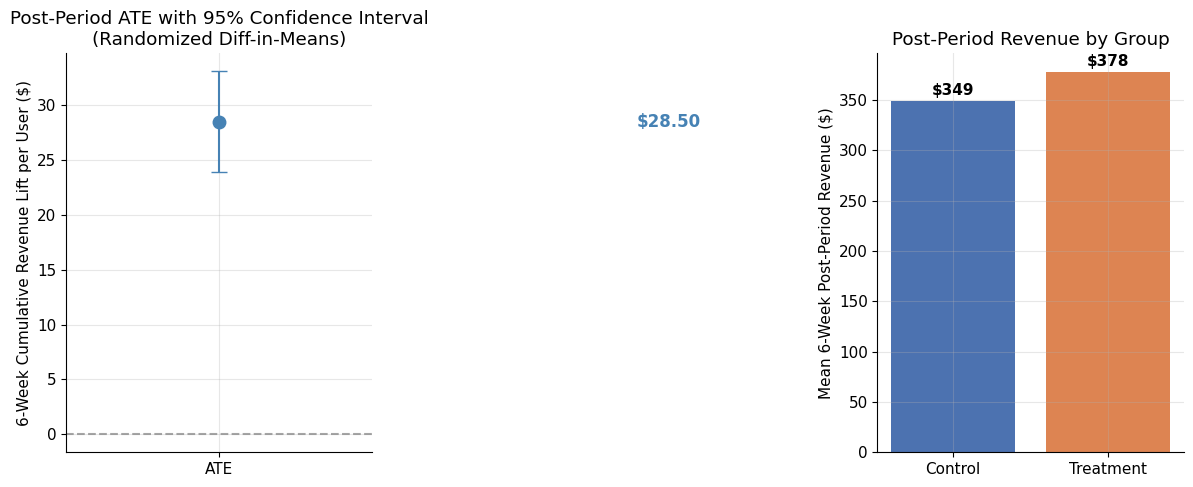

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(
    x=[0], y=[ate_lift],
    yerr=[[ate_lift - ate_ci_low], [ate_ci_high - ate_lift]],
    fmt="o", capsize=6, markersize=9, color="steelblue",
)
axes[0].axhline(0, linestyle="--", color="gray", alpha=0.7)
axes[0].annotate(
    f"${ate_lift:.2f}",
    xy=(0, ate_lift), xytext=(0.15, ate_lift),
    fontsize=12, fontweight="bold", color="steelblue", va="center",
)
axes[0].set_xticks([0])
axes[0].set_xticklabels(["ATE"])
axes[0].set_ylabel("6-Week Cumulative Revenue Lift per User ($)")
axes[0].set_title("Post-Period ATE with 95% Confidence Interval\n(Randomized Diff-in-Means)")

bars = axes[1].bar(["Control", "Treatment"], [ctrl.mean(), treat.mean()],
                   color=["#4C72B0", "#DD8452"])
for bar, val in zip(bars, [ctrl.mean(), treat.mean()]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"${val:.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Mean 6-Week Post-Period Revenue ($)")
axes[1].set_title("Post-Period Revenue by Group")

plt.tight_layout()
plt.show()

**Interpretation:**

Post-period ATE: **+$28.50 per user (+8.16%)**, 95% CI [$23.90, $33.11]. The confidence interval does
not cross zero, confirming statistical significance at the 5% level.

Because treatment was randomized, this estimate provides the most credible measure of the promotion's
average causal impact. Panel-based methods (DiD, TWFE) serve as robustness and diagnostic checks.

## 3. Panel Dataset Construction

Build a user-week panel (pre and post) for high-LTV users. This panel is the basis for all
Difference-in-Differences, event-study, and synthetic-control analyses.

In [4]:
panel_df = pd.read_sql("""
    select user_id, treatment_flag, high_ltv_flag, pre_post_flag, revenue_sim
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1
      and pre_post_flag in ('pre', 'post')
""", conn)

panel_df["user_id"]          = panel_df["user_id"].astype(int)
panel_df["post"]             = (panel_df["pre_post_flag"] == "post").astype(int)
panel_df["interaction"]      = panel_df["treatment_flag"] * panel_df["post"]
panel_df["revenue_demeaned"] = (
    panel_df["revenue_sim"]
    - panel_df.groupby("user_id")["revenue_sim"].transform("mean")
)

panel_df = panel_df.sort_values("user_id").copy()

if "week_index" not in panel_df.columns:
    panel_df["week_index"] = panel_df.groupby("user_id").cumcount() + 1
panel_df["week_index"] = panel_df["week_index"].astype(int)

# Export for Streamlit app
panel_df.to_csv("../data/processed/panel_df.csv", index=False)

print(f"Panel: {len(panel_df):,} rows | {panel_df['user_id'].nunique():,} users | "
      f"{panel_df['week_index'].nunique()} weeks")
panel_df.head()

Panel: 440,501 rows | 61,863 users | 12 weeks


,user_id,treatment_flag,high_ltv_flag,pre_post_flag,revenue_sim,post,interaction,revenue_demeaned,week_index
221309,2,1,1,pre,76.4400,0,0,-12.493086,1
221308,2,1,1,pre,75.6300,0,0,-13.303086,2
221311,2,1,1,pre,68.5000,0,0,-20.433086,3
221310,2,1,1,pre,83.6100,0,0,-5.323086,4
221313,2,1,1,post,80.6436,1,1,-8.289486,5


## 4. Event Study

Estimate treatment effects week-by-week relative to the final pre-treatment period (t = −1)
using two-way fixed effects (TWFE). This tests whether pre-treatment trends were parallel and
shows how treatment effects evolve after the promotion begins.

In [5]:
# Working copy for event-study and TWFE models
df = panel_df[["user_id", "treatment_flag", "pre_post_flag", "week_index", "revenue_sim"]].dropna().copy()
df["user_id"]     = df["user_id"].astype(str)
df["week_index"]  = df["week_index"].astype(int)
df["revenue_sim"] = df["revenue_sim"].astype(float)

# Map calendar weeks to event time (weeks 1–6 = pre, 7–12 = post)
week_map = {1: -6, 2: -5, 3: -4, 4: -3, 5: -2, 6: -1,
            7:  0, 8:  1, 9:  2, 10: 3, 11: 4, 12: 5}
df["event_time"]    = df["week_index"].map(week_map)
df["pre_post_flag"] = np.where(df["week_index"] <= 6, 0, 1)

# Treatment x week interaction dummies (reference week = -1, omitted)
reference_week   = -1
interaction_cols = []
for w in sorted(df["event_time"].unique()):
    if w == reference_week:
        continue
    col = f"event_{w}"
    df[col] = ((df["event_time"] == w) & (df["treatment_flag"] == 1)).astype(int)
    interaction_cols.append(col)

In [6]:
y_tilde = twfe_residualize(df, "revenue_sim")
X_tilde = pd.DataFrame(
    {col: twfe_residualize(df, col) for col in interaction_cols},
    index=df.index,
)

event_model = sm.OLS(y_tilde, X_tilde).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]},
)

event_results = pd.DataFrame({
    "term": event_model.params.index,
    "coef": event_model.params.values,
    "se":   event_model.bse.values,
})
event_results["event_time"] = (
    event_results["term"].str.replace("event_", "", regex=False).astype(int)
)
event_results["ci_low"]  = event_results["coef"] - 1.96 * event_results["se"]
event_results["ci_high"] = event_results["coef"] + 1.96 * event_results["se"]

# Add reference period (t = -1 is omitted; coefficient = 0 by construction)
ref_row = pd.DataFrame([{
    "term": "reference", "coef": 0.0, "se": 0.0,
    "event_time": -1, "ci_low": 0.0, "ci_high": 0.0,
}])
event_results = (
    pd.concat([event_results, ref_row], ignore_index=True)
    .sort_values("event_time")
    .reset_index(drop=True)
)

event_results.to_csv("../data/processed/event_study.csv", index=False)
event_results

,term,coef,se,event_time,ci_low,ci_high
0,event_-6,1.924101,0.694233,-6,0.563404,3.284799
1,event_-5,2.038739,0.696548,-5,0.673505,3.403974
2,event_-4,2.101166,0.692302,-4,0.744254,3.458079
3,event_-3,1.135708,0.701985,-3,-0.240182,2.511599
4,event_-2,1.209085,0.725442,-2,-0.212783,2.630952
5,reference,0.000000,0.000000,-1,0.000000,0.000000
6,event_0,-0.645675,0.790270,0,-2.194604,0.903255
7,event_1,-0.198008,0.849511,1,-1.863049,1.467032
8,event_2,0.236961,0.935004,2,-1.595647,2.069568
9,event_3,0.026507,1.068042,3,-2.066856,2.119870


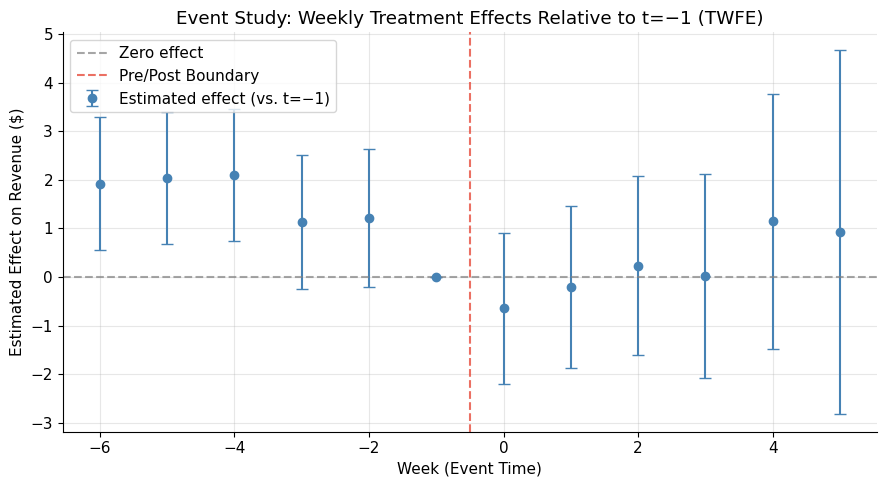

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    event_results["event_time"],
    event_results["coef"],
    yerr=[
        event_results["coef"] - event_results["ci_low"],
        event_results["ci_high"] - event_results["coef"],
    ],
    fmt="o", capsize=4, color="steelblue", label="Estimated effect (vs. t=−1)",
)
ax.axhline(0, linestyle="--", color="gray", alpha=0.7, label="Zero effect")
ax.axvline(-0.5, linestyle="--", color="#e74c3c", alpha=0.8, label="Pre/Post Boundary")
ax.set_xlabel("Week (Event Time)")
ax.set_ylabel("Estimated Effect on Revenue ($)")
ax.set_title("Event Study: Weekly Treatment Effects Relative to t=−1 (TWFE)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation

The event study estimates per-week treatment effects relative to t = -1 (the final pre-treatment
week), controlling for user and time fixed effects.

Pre-treatment coefficients are modestly positive, suggesting treated users had somewhat higher
revenue relative to the chosen reference period. This pattern may be sensitive to the reference
period choice, so it does not constitute definitive evidence of a parallel-trends violation.

Post-treatment coefficients are near zero, consistent with the TWFE aggregate estimate of -$1.58.
This divergence from the post-period ATE (+$28.50) reflects the TWFE specification's sensitivity
to pre-period differences. The randomized ATE remains the primary causal estimate.

In [8]:
pre_terms = [c for c in interaction_cols if int(c.split("_", 1)[1]) < 0]
R = np.zeros((len(pre_terms), len(event_model.params)))
for i, term in enumerate(pre_terms):
    R[i, list(event_model.params.index).index(term)] = 1

f_test = event_model.f_test(R)
print(f_test)

<F test: F=2.6904088462221147, p=0.01950048176240322, df_denom=6.19e+04, df_num=5>


A joint F-test rejects the null that all pre-treatment coefficients are zero relative to the
omitted reference period (t = -1). This warrants caution when interpreting DiD estimates, though
the conclusion may be sensitive to the reference period choice. Panel-based estimates are used
as robustness checks throughout this analysis.

## 5. Propensity Score Weighting

To improve pre-treatment comparability, we estimate propensity scores via logistic regression on
pre-period characteristics and apply inverse probability weights (IPW) to the DiD model.

In [9]:
ps_df = (
    panel_df[panel_df["pre_post_flag"] == "pre"]
    .groupby("user_id")
    .agg(
        baseline_revenue=("revenue_sim", "mean"),
        pre_rev_std=("revenue_sim", "std"),
        pre_weeks=("revenue_sim", "count"),
        treatment_flag=("treatment_flag", "max"),
    )
    .reset_index()
)
ps_df["pre_rev_std"] = ps_df["pre_rev_std"].fillna(0)

logit = LogisticRegression(max_iter=1000)
logit.fit(ps_df[["baseline_revenue", "pre_rev_std", "pre_weeks"]], ps_df["treatment_flag"])
ps_df["propensity_score"] = logit.predict_proba(
    ps_df[["baseline_revenue", "pre_rev_std", "pre_weeks"]]
)[:, 1]

ps_df["weight"] = (
    ps_df["treatment_flag"] / ps_df["propensity_score"]
    + (1 - ps_df["treatment_flag"]) / (1 - ps_df["propensity_score"])
)

panel_w = panel_df.merge(ps_df[["user_id", "weight"]], on="user_id", how="left")

X_w = sm.add_constant(panel_w[["treatment_flag", "post", "interaction"]])
did_weighted = sm.WLS(panel_w["revenue_sim"], X_w, weights=panel_w["weight"]).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_w["user_id"]},
)

weighted_coef    = did_weighted.params["interaction"]
weighted_se      = did_weighted.bse["interaction"]
weighted_ci_low  = weighted_coef - 1.96 * weighted_se
weighted_ci_high = weighted_coef + 1.96 * weighted_se

print(f"Weighted DiD lift: ${weighted_coef:.2f}  "
      f"(95% CI: ${weighted_ci_low:.2f}, ${weighted_ci_high:.2f})")

Weighted DiD lift: $8.61  (95% CI: $7.76, $9.47)


After reweighting on observed pre-treatment characteristics, the estimated treatment effect is
**+$8.61 per user-week** (95% CI: [$7.76, $9.47]).

This is similar to the naive DiD, suggesting observable pre-period differences explain little of
the divergence. The large contrast with the TWFE estimate (-$1.58) highlights sensitivity to
specification choice and reinforces that no panel method fully substitutes for the randomized ATE.

## 6. Difference-in-Differences Models

### 6.1 Clustered DiD

In [10]:
X_did = sm.add_constant(panel_df[["treatment_flag", "post", "interaction"]])
did_cluster = sm.OLS(panel_df["revenue_sim"], X_did).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]},
)

did_res = coef_line(did_cluster)
print(f"Clustered DiD weekly lift: ${did_res['coef']:.2f}  "
      f"(95% CI: ${did_res['ci_low']:.2f}, ${did_res['ci_high']:.2f})")

Clustered DiD weekly lift: $8.74  (95% CI: $7.90, $9.59)


The baseline DiD estimates a weekly lift of **+$8.74** (95% CI: [$7.90, $9.59]). This specification
does not control for user-level heterogeneity, so the estimate may be biased if treated and control
users differ systematically in time-invariant characteristics.

### 6.2 User Fixed Effects DiD

In [11]:
X_fe = sm.add_constant(panel_df[["post", "interaction"]])
fe_cluster = sm.OLS(panel_df["revenue_demeaned"], X_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]},
)

fe_res = coef_line(fe_cluster)
print(f"User FE DiD weekly lift: ${fe_res['coef']:.2f}  "
      f"(95% CI: ${fe_res['ci_low']:.2f}, ${fe_res['ci_high']:.2f})")

User FE DiD weekly lift: $4.53  (95% CI: $4.13, $4.93)


Controlling for time-invariant user heterogeneity, the estimate falls to **+$4.53/week**
(95% CI: [$4.13, $4.93]). The reduction from the naive estimate confirms that user-level fixed
effects absorb a portion of the estimated lift.

### 6.3 Two-Way Fixed Effects DiD

In [12]:
df["did"] = df["treatment_flag"] * df["pre_post_flag"]
y_twfe    = twfe_residualize(df, "revenue_sim")
did_twfe  = twfe_residualize(df, "did")

twfe_model = sm.OLS(y_twfe, pd.DataFrame({"did": did_twfe}, index=df.index)).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]},
)

twfe_coef    = twfe_model.params["did"]
twfe_se      = twfe_model.bse["did"]
twfe_ci_low  = twfe_coef - 1.96 * twfe_se
twfe_ci_high = twfe_coef + 1.96 * twfe_se

print(f"Two-Way FE DiD weekly lift: ${twfe_coef:.2f}  "
      f"(95% CI: ${twfe_ci_low:.2f}, ${twfe_ci_high:.2f})")

Two-Way FE DiD weekly lift: $-1.58  (95% CI: $-2.26, $-0.89)


The TWFE estimate is **-$1.58/week** (95% CI: [-$2.26, -$0.89]), absorbing both user and week
fixed effects. This negative result, combined with the event-study diagnostics, reflects the
specification's sensitivity to pre-treatment trend differences. It is treated as a robustness
check rather than the primary estimate.

In [13]:
# Synthetic control computation — run here so sc_effect is available for the model comparison table
sc_df = df[["user_id", "treatment_flag", "event_time", "revenue_sim"]].copy()

baseline = (
    sc_df[sc_df["event_time"] < 0]
    .groupby("user_id")["revenue_sim"]
    .mean()
    .reset_index(name="baseline_revenue")
)
sc_df = sc_df.merge(baseline, on="user_id", how="left")

control_users = (
    sc_df[sc_df["treatment_flag"] == 0][["user_id", "baseline_revenue"]]
    .drop_duplicates()
    .copy()
)
control_users["donor_bin"] = pd.qcut(
    control_users["baseline_revenue"], q=10, labels=False, duplicates="drop"
)
sc_df = sc_df.merge(control_users[["user_id", "donor_bin"]], on="user_id", how="left")

treated_series = (
    sc_df[sc_df["treatment_flag"] == 1]
    .groupby("event_time")["revenue_sim"].mean().sort_index()
)
donor_panel = (
    sc_df[sc_df["treatment_flag"] == 0]
    .groupby(["event_time", "donor_bin"])["revenue_sim"]
    .mean().unstack().sort_index()
)

common_times   = treated_series.index.intersection(donor_panel.index)
treated_series = treated_series.loc[common_times]
donor_panel    = donor_panel.loc[common_times]

pre_periods = treated_series.index[treated_series.index < 0]
Y_pre       = treated_series.loc[pre_periods].values
D_pre       = donor_panel.loc[pre_periods].values
n_donors    = D_pre.shape[1]

result = minimize(
    lambda w: np.mean((Y_pre - D_pre @ w) ** 2),
    np.ones(n_donors) / n_donors,
    method="SLSQP",
    bounds=[(0, 1)] * n_donors,
    constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
)

synthetic_series = pd.Series(donor_panel.values @ result.x, index=donor_panel.index)
sc_effect_series = treated_series - synthetic_series

post_periods = treated_series.index[treated_series.index >= 0]
sc_effect    = sc_effect_series.loc[post_periods].mean()
sc_fit_rmse  = np.sqrt(np.mean(sc_effect_series.loc[pre_periods] ** 2))

## 7. Model Comparison

,Model,Lift ($/week),95% CI,Notes
0,TWFE DiD,-1.58,"[$-2.26, $-0.89]",Two-way FE; most restrictive; sensitive to pre...
1,Synthetic Control,2.11,—,Synthetic-control check; more conservative est...
2,User FE DiD,4.53,"[$4.13, $4.93]",Controls for time-invariant user characteristics
3,Weighted DiD,8.61,"[$7.76, $9.47]",IPW-reweighted robustness check
4,Naive DiD,8.74,"[$7.90, $9.59]",Baseline; does not control for user heterogeneity


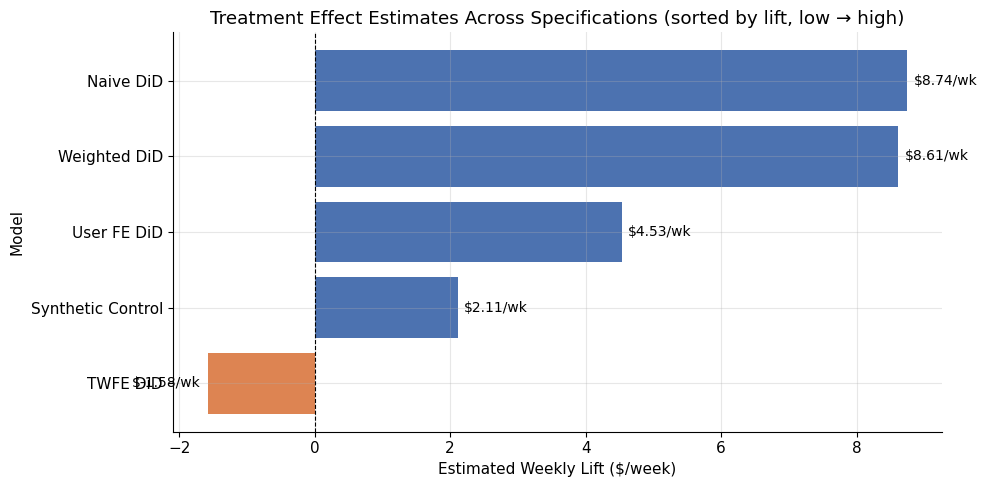

In [14]:
results_table = pd.DataFrame({
    "Model": ["TWFE DiD", "Synthetic Control", "User FE DiD", "Weighted DiD", "Naive DiD"],
    "Lift ($/week)": [
        round(twfe_coef, 2),
        round(sc_effect, 2),
        fe_res["coef"],
        round(weighted_coef, 2),
        did_res["coef"],
    ],
    "95% CI": [
        f"[${twfe_ci_low:.2f}, ${twfe_ci_high:.2f}]",
        "—",
        f"[${fe_res['ci_low']:.2f}, ${fe_res['ci_high']:.2f}]",
        f"[${weighted_ci_low:.2f}, ${weighted_ci_high:.2f}]",
        f"[${did_res['ci_low']:.2f}, ${did_res['ci_high']:.2f}]",
    ],
    "Notes": [
        "Two-way FE; most restrictive; sensitive to pre-trends",
        "Synthetic-control check; more conservative estimate",
        "Controls for time-invariant user characteristics",
        "IPW-reweighted robustness check",
        "Baseline; does not control for user heterogeneity",
    ],
})

display(results_table)

colors = ["#DD8452" if v < 0 else "#4C72B0" for v in results_table["Lift ($/week)"]]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_table["Model"], results_table["Lift ($/week)"], color=colors)
for bar, val in zip(bars, results_table["Lift ($/week)"]):
    xpos = val + 0.1 if val >= 0 else val - 0.1
    ha   = "left"    if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"${val:.2f}/wk", va="center", ha=ha, fontsize=10)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Treatment Effect Estimates Across Specifications (sorted by lift, low → high)")
ax.set_xlabel("Estimated Weekly Lift ($/week)")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

Treatment effect estimates range from **-$1.58** (TWFE) to **+$8.74** (Naive DiD), illustrating
substantial sensitivity to modeling assumptions. Simpler specifications produce larger estimates
because they do not absorb user heterogeneity or time fixed effects.

The weighted DiD partially recovers a positive estimate by rebalancing observable characteristics;
the synthetic control provides a more conservative alternative counterfactual. Neither resolves
the underlying sensitivity to pre-treatment differences.

The randomized post-period ATE (+$28.50 cumulative, ~+$8.50/week) remains the most credible
estimate of average causal impact.

## 8. Synthetic Control Robustness Check

The synthetic control constructs a weighted combination of control cohorts that best matches the
treated group's pre-treatment revenue trajectory, providing an alternative counterfactual that is
less sensitive to the parallel-trends assumption than standard DiD.

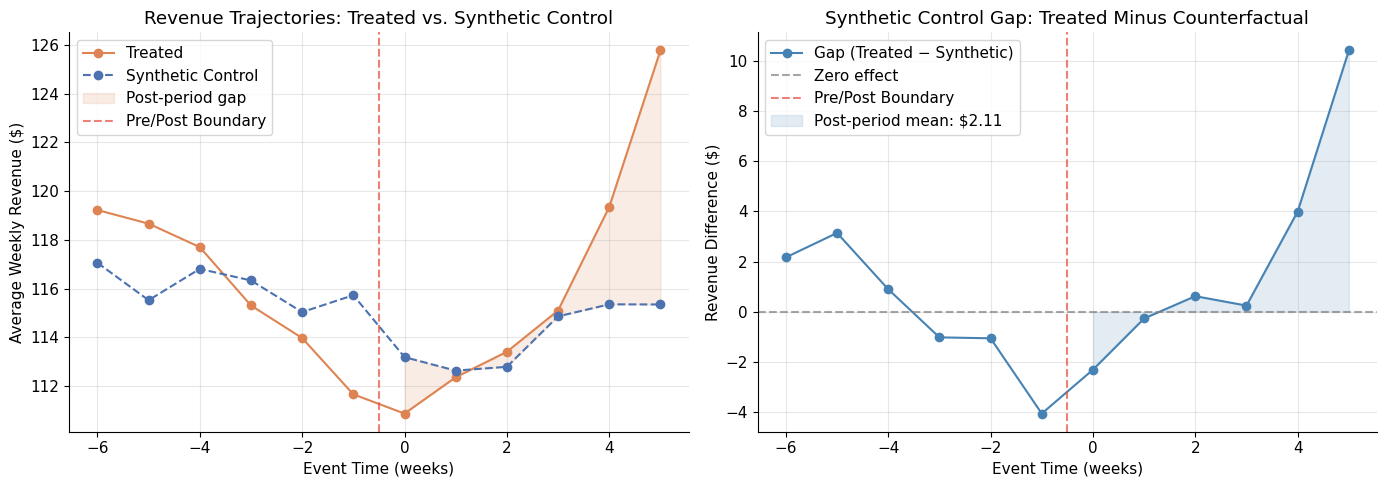

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(treated_series.index, treated_series.values,
             marker="o", color="#DD8452", label="Treated")
axes[0].plot(synthetic_series.index, synthetic_series.values,
             marker="o", linestyle="--", color="#4C72B0", label="Synthetic Control")
axes[0].fill_between(
    treated_series.index, treated_series.values, synthetic_series.values,
    where=(treated_series.index >= 0),
    alpha=0.15, color="#DD8452", label="Post-period gap",
)
axes[0].axvline(-0.5, linestyle="--", color="#e74c3c", alpha=0.7, label="Pre/Post Boundary")
axes[0].set_title("Revenue Trajectories: Treated vs. Synthetic Control")
axes[0].set_xlabel("Event Time (weeks)")
axes[0].set_ylabel("Average Weekly Revenue ($)")
axes[0].legend()

axes[1].plot(sc_effect_series.index, sc_effect_series.values,
             marker="o", color="steelblue", label="Gap (Treated − Synthetic)")
axes[1].axhline(0, linestyle="--", color="gray", alpha=0.7, label="Zero effect")
axes[1].axvline(-0.5, linestyle="--", color="#e74c3c", alpha=0.7, label="Pre/Post Boundary")
axes[1].fill_between(
    sc_effect_series.index, sc_effect_series.values, 0,
    where=(sc_effect_series.index >= 0),
    alpha=0.15, color="steelblue", label=f"Post-period mean: ${sc_effect:.2f}",
)
axes[1].set_title("Synthetic Control Gap: Treated Minus Counterfactual")
axes[1].set_xlabel("Event Time (weeks)")
axes[1].set_ylabel("Revenue Difference ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

The synthetic control estimates a post-period effect of approximately **+$2.11/user**, with a
pre-period fit RMSE of 2.38, indicating reasonable pre-period tracking.

This is smaller than the naive DiD (+$8.74), consistent with the pattern that more carefully
constructed counterfactuals yield more conservative estimates. This result should be interpreted
as an additional robustness check — not the primary estimate.

## 9. Business Impact

In [16]:
discount_rate = 0.10

treated_post_rev = panel_df.loc[
    (panel_df["treatment_flag"] == 1) & (panel_df["post"] == 1), "revenue_sim"
].mean()
control_post_rev = panel_df.loc[
    (panel_df["treatment_flag"] == 0) & (panel_df["post"] == 1), "revenue_sim"
].mean()

weekly_ate    = treated_post_rev - control_post_rev
discount_cost = treated_post_rev * discount_rate
net_impact    = weekly_ate - discount_cost

num_treated   = panel_df.loc[panel_df["treatment_flag"] == 1, "user_id"].nunique()
total_impact  = net_impact * num_treated

pd.DataFrame({
    "Metric": [
        "Weekly ATE Lift",
        "Estimated Discount Cost (10% of treated revenue)",
        "Net Impact per User per Week",
        "Total Weekly Campaign Impact",
    ],
    "Value": [
        f"${weekly_ate:+.2f}",
        f"-${discount_cost:.2f}",
        f"${net_impact:+.2f}",
        f"${total_impact:,.0f}",
    ],
})

,Metric,Value
0,Weekly ATE Lift,$+8.50
1,Estimated Discount Cost (10% of treated revenue),-$11.49
2,Net Impact per User per Week,$-2.99
3,Total Weekly Campaign Impact,"$-92,409"


The weekly ATE lift (~+$8.50) does not cover the estimated discount cost (~$11.49), yielding a
net impact of approximately **-$2.99 per user per week**. A blanket 10% discount is unprofitable
under a short-term revenue objective.

**Caveats:** Revenue is simulated. A real deployment requires validation against observed transaction
data, margin impact, cannibalization effects, inventory costs, and downstream retention outcomes.

**Strategic context:** A short-term loss may be acceptable if the promotion drives trial, customer
acquisition, repeat purchase, or inventory clearance. The profitability threshold depends on the
discount rate, targeting strategy, and lifetime value uplift.

## 10. Heterogeneous Treatment Effects

Estimate treatment lift by baseline spend quartile to evaluate whether the promotion's impact
varies systematically across user segments.

In [17]:
post_df = pd.read_sql("select * from analysis.post_user_summary", conn)

pre_df = pd.read_sql("""
    select user_id, treatment_flag, sum(revenue_sim) as pre_revenue
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1 and pre_post_flag = 'pre'
    group by 1, 2
""", conn)

for d in (post_df, pre_df):
    d["user_id"]        = d["user_id"].astype(int)
    d["treatment_flag"] = d["treatment_flag"].astype(int)

hte_df = post_df.merge(pre_df, on=["user_id", "treatment_flag"], how="inner")
hte_df["baseline_quartile"] = pd.qcut(
    hte_df["pre_revenue"], 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)

hte_summary = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .mean().unstack().reset_index()
    .rename(columns={0: "control_mean", 1: "treatment_mean"})
)
hte_summary["lift"]     = hte_summary["treatment_mean"] - hte_summary["control_mean"]
hte_summary["pct_lift"] = hte_summary["lift"] / hte_summary["control_mean"] * 100
hte_summary.round(2)

treatment_flag,baseline_quartile,control_mean,treatment_mean,lift,pct_lift
0,Q1 Low,224.66,243.74,19.08,8.49
1,Q2,269.44,289.65,20.21,7.50
2,Q3,340.26,371.22,30.96,9.10
3,Q4 High,561.64,608.48,46.84,8.34


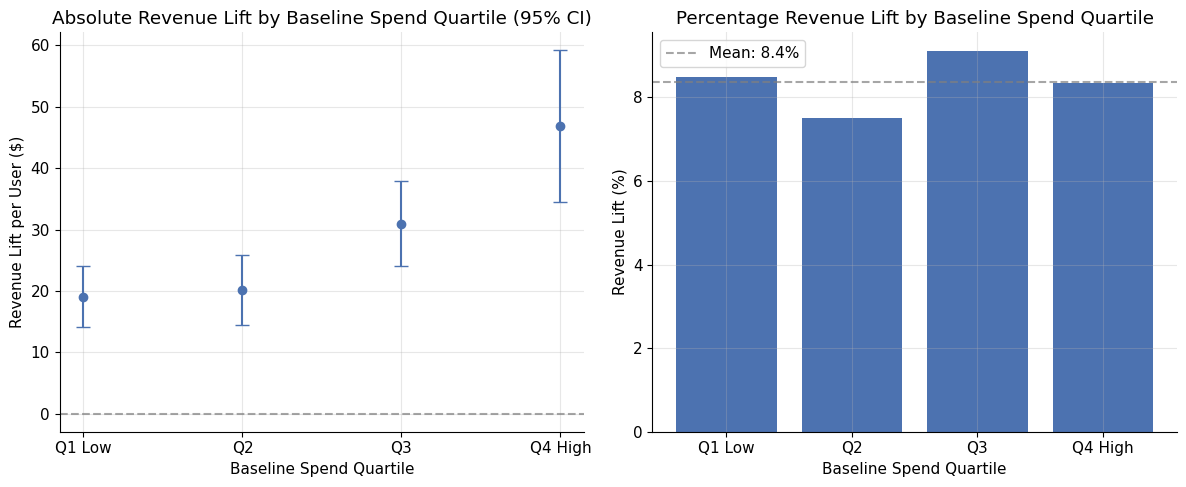

In [18]:
hte_ci = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .agg(["mean", "std", "count"]).reset_index()
)
hte_ci["se"] = hte_ci["std"] / np.sqrt(hte_ci["count"])

ctrl_ci  = hte_ci[hte_ci["treatment_flag"] == 0]
treat_ci = hte_ci[hte_ci["treatment_flag"] == 1]

lift_df = ctrl_ci[["baseline_quartile", "mean", "se"]].merge(
    treat_ci[["baseline_quartile", "mean", "se"]],
    on="baseline_quartile", suffixes=("_control", "_treat"),
)
lift_df["lift"]    = lift_df["mean_treat"] - lift_df["mean_control"]
lift_df["se_lift"] = np.sqrt(lift_df["se_control"] ** 2 + lift_df["se_treat"] ** 2)
lift_df["ci_low"]  = lift_df["lift"] - 1.96 * lift_df["se_lift"]
lift_df["ci_high"] = lift_df["lift"] + 1.96 * lift_df["se_lift"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(
    lift_df["baseline_quartile"], lift_df["lift"],
    yerr=1.96 * lift_df["se_lift"],
    fmt="o", capsize=5, color="#4C72B0",
)
axes[0].axhline(0, linestyle="--", color="gray", alpha=0.7)
axes[0].set_title("Absolute Revenue Lift by Baseline Spend Quartile (95% CI)")
axes[0].set_xlabel("Baseline Spend Quartile")
axes[0].set_ylabel("Revenue Lift per User ($)")

axes[1].bar(hte_summary["baseline_quartile"], hte_summary["pct_lift"], color="#4C72B0")
axes[1].axhline(hte_summary["pct_lift"].mean(), linestyle="--", color="gray", alpha=0.7,
                label=f"Mean: {hte_summary['pct_lift'].mean():.1f}%")
axes[1].set_title("Percentage Revenue Lift by Baseline Spend Quartile")
axes[1].set_xlabel("Baseline Spend Quartile")
axes[1].set_ylabel("Revenue Lift (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
q4_lift = hte_summary.loc[hte_summary["baseline_quartile"] == "Q4 High", "lift"].values[0]
q1_lift = hte_summary.loc[hte_summary["baseline_quartile"] == "Q1 Low",  "lift"].values[0]
q4_pct  = hte_summary.loc[hte_summary["baseline_quartile"] == "Q4 High", "pct_lift"].values[0]
q1_pct  = hte_summary.loc[hte_summary["baseline_quartile"] == "Q1 Low",  "pct_lift"].values[0]

display(Markdown(f"""
Treatment lift is positive and statistically significant across all four quartiles. Higher-spend
users generate larger **absolute** dollar gains (${q4_lift:.2f} for Q4 High vs. ${q1_lift:.2f} for Q1 Low).

**Percentage lift** is broadly similar across segments (~{q1_pct:.1f}–{q4_pct:.1f}%), indicating that higher baseline
revenue — not stronger causal responsiveness — drives the dollar gap. Simple baseline-spend targeting
within the high-LTV population would not meaningfully improve the promotion's efficiency.
"""))


Treatment lift is positive and statistically significant across all four quartiles. Higher-spend
users generate larger **absolute** dollar gains ($46.84 for Q4 High vs. $19.08 for Q1 Low).

**Percentage lift** is broadly similar across segments (~8.5–8.3%), indicating that higher baseline
revenue — not stronger causal responsiveness — drives the dollar gap. Simple baseline-spend targeting
within the high-LTV population would not meaningfully improve the promotion's efficiency.


## 11. Causal Forest

We complement the quartile analysis with a causal forest (`CausalForestDML`), which estimates
individual-level treatment effects and identifies which users are most responsive to the promotion.

Because event-study diagnostics show non-zero pre-treatment coefficients, these estimates are
exploratory. A follow-up experiment is required before deploying model-based targeting in production.

In [20]:
cf_df = panel_df.copy()
cf_df["pre_post_flag"] = cf_df["pre_post_flag"].astype(str).str.strip().str.lower()

pre_user = (
    cf_df[cf_df["pre_post_flag"] == "pre"]
    .groupby("user_id")
    .agg(
        baseline_revenue=("revenue_sim", "mean"),
        pre_rev_std=("revenue_sim", "std"),
        pre_weeks=("revenue_sim", "count"),
        treatment_flag=("treatment_flag", "max"),
    )
    .reset_index()
)
pre_user["pre_rev_std"] = pre_user["pre_rev_std"].fillna(0)

post_user = (
    cf_df[cf_df["pre_post_flag"] == "post"]
    .groupby("user_id")
    .agg(post_revenue=("revenue_sim", "mean"))
    .reset_index()
)

user_cf = pre_user.merge(post_user, on="user_id", how="inner").dropna().copy()

Y = user_cf["post_revenue"].to_numpy()
T = user_cf["treatment_flag"].to_numpy()
X = user_cf[["baseline_revenue", "pre_rev_std", "pre_weeks"]].to_numpy()

cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    n_estimators=200, min_samples_leaf=10, random_state=42,
)
cf.fit(Y, T, X=X)
user_cf["te_pred"] = cf.effect(X)

user_cf["te_pred"].agg(["mean", "std", "min", "max"]).round(2).rename("Value").to_frame()

,Value
mean,8.40
std,5.57
min,-13.73
max,46.33


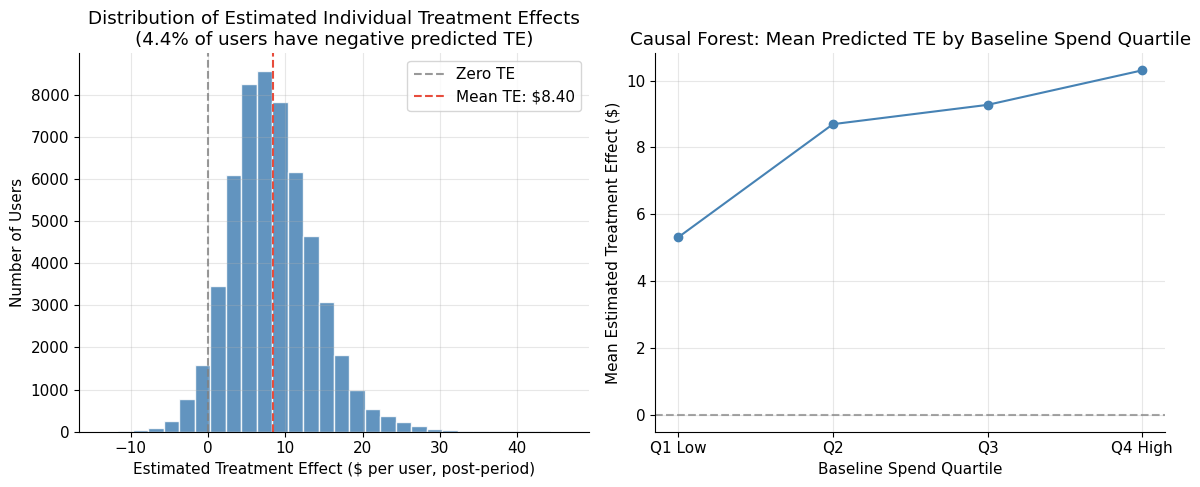

In [21]:
user_cf["baseline_quartile"] = pd.qcut(
    user_cf["baseline_revenue"], 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)
cf_hte_summary = user_cf.groupby("baseline_quartile")["te_pred"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(user_cf["te_pred"], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, linestyle="--", color="gray", alpha=0.8, label="Zero TE")
axes[0].axvline(
    user_cf["te_pred"].mean(), linestyle="--", color="#e74c3c",
    label=f"Mean TE: ${user_cf['te_pred'].mean():.2f}",
)
pct_neg = (user_cf["te_pred"] < 0).mean() * 100
axes[0].set_title(
    f"Distribution of Estimated Individual Treatment Effects\n"
    f"({pct_neg:.1f}% of users have negative predicted TE)"
)
axes[0].set_xlabel("Estimated Treatment Effect ($ per user, post-period)")
axes[0].set_ylabel("Number of Users")
axes[0].legend()

axes[1].plot(cf_hte_summary["baseline_quartile"], cf_hte_summary["te_pred"],
             marker="o", color="steelblue")
axes[1].axhline(0, linestyle="--", color="gray", alpha=0.7)
axes[1].set_title("Causal Forest: Mean Predicted TE by Baseline Spend Quartile")
axes[1].set_xlabel("Baseline Spend Quartile")
axes[1].set_ylabel("Mean Estimated Treatment Effect ($)")

plt.tight_layout()
plt.show()

In [22]:
threshold   = user_cf["te_pred"].quantile(0.8)
top_users   = user_cf[user_cf["te_pred"] >= threshold]
other_users = user_cf[user_cf["te_pred"] < threshold]

pd.DataFrame({
    "Segment": ["Top 20% (highest predicted TE)", "Bottom 80%"],
    "Users": [len(top_users), len(other_users)],
    "Mean Predicted TE ($)": [
        round(top_users["te_pred"].mean(), 2),
        round(other_users["te_pred"].mean(), 2),
    ],
})

,Segment,Users,Mean Predicted TE ($)
0,Top 20% (highest predicted TE),11021,16.55
1,Bottom 80%,44081,6.36


In [23]:
cf_mean    = user_cf["te_pred"].mean()
cf_std     = user_cf["te_pred"].std()
cf_min     = user_cf["te_pred"].min()
cf_max     = user_cf["te_pred"].max()
top_mean   = top_users["te_pred"].mean()
other_mean = other_users["te_pred"].mean()

display(Markdown(f"""
The causal forest identifies meaningful variation in predicted treatment effects: mean **${cf_mean:.2f}**,
SD **${cf_std:.2f}**, range [${cf_min:.2f}, +${cf_max:.2f}].

The top 20% of users by predicted TE have a mean effect of **${top_mean:.2f}**, versus **${other_mean:.2f}** for the
remaining 80%. Targeting this segment could substantially improve the promotion's ROI relative to a
blanket rollout. These are model-based predictions and must be validated in a follow-up experiment
before deployment.
"""))


The causal forest identifies meaningful variation in predicted treatment effects: mean **$8.40**,
SD **$5.57**, range [$-13.73, +$46.33].

The top 20% of users by predicted TE have a mean effect of **$16.55**, versus **$6.36** for the
remaining 80%. Targeting this segment could substantially improve the promotion's ROI relative to a
blanket rollout. These are model-based predictions and must be validated in a follow-up experiment
before deployment.


## Business Implications

The randomized experiment provides credible evidence of a positive revenue lift from the 10%
discount. However, average weekly lift (~+$8.50) does not cover the estimated discount cost
(~$11.49), so a blanket rollout is not profitable under a short-term revenue objective.

The business decision depends on strategic context:
- **Profitability objective:** Avoid blanket rollout; test lower discount levels (5-7%) or targeted rollout to high-TE users
- **Trial or acquisition objective:** Short-term loss may be acceptable if the promotion drives durable repeat purchase or category expansion
- **Inventory objective:** Discount may be justified if it clears slow-moving inventory and reduces holding costs

## Limitations & Future Work

- **Revenue is simulated** (deterministic 8% uplift on treated post-period rows); real-world results require validation against observed transaction data
- **Simplified discount model:** actual cost depends on product margins, cannibalization, inventory effects, and lifetime value
- **Pre-treatment differences** in the event study suggest caution with DiD estimates; magnitude may be sensitive to the reference period choice
- **Causal forest targets are exploratory:** model-based HTE estimates require a validation experiment before deployment
- **Future improvements:** stratified randomization by baseline spend quartile, richer feature sets for the causal forest, longer pre-treatment windows

## Business Recommendation

1. **Do not broadly deploy** the 10% discount at current levels if the objective is short-term profitability
2. **Explore lower discount rates** (5-7%) to find a profitable threshold
3. **Use stratified randomization** in future experiments to ensure balance across spend segments
4. **Run a validation experiment** targeting the top predicted-TE segment from the causal forest before operationalizing ML-driven targeting
5. **Track downstream outcomes** (repeat purchase, retention, margin) to capture the full value of the promotion

## Final Takeaway

The randomized experiment provides the most credible causal estimate: **+$28.50 per user cumulative over 6 post-period weeks** (95% CI [$23.90, $33.11]). This comes from a randomized diff-in-means on post-period revenue — **not** from dividing the panel-based weekly lift.

The weekly DiD panel estimate is approximately **+$8.50/week** — a separate estimate from the panel models, not $28.50 ÷ 6 ≈ $4.75/week. The business-impact calculation uses this weekly panel figure: at a 10% blanket discount (~$11.49/week cost), the promotion is **not profitable** in the short term.

DiD estimates span a wide range (−$1.58 to +$8.74/week), reflecting specification sensitivity rather than genuine uncertainty about the causal effect. The event study is diagnostic, not dispositive.

The key actionable insight is that **targeted discounting** — focusing the promotion on high-TE users identified by the causal forest — has the potential to substantially improve profitability. Quantifying that improvement requires a follow-up experiment.

---

# Appendix

Full regression outputs for all DiD specifications. Focus on the `interaction` (or `did`) coefficient,
its clustered standard error, and the 95% confidence interval.

### A1. Clustered Difference-in-Differences

In [24]:
display(did_cluster.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            revenue_sim   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     431.1
Date:                Wed, 27 May 2026   Prob (F-statistic):          3.31e-277
Time:                        16:20:22   Log-Likelihood:            -2.5086e+06
No. Observations:              440501   AIC:                         5.017e+06
Df Residuals:                  440497   BIC:                         5.017e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            116.5163      0.317    367.547      0.000     115.895     117.138
treatment_flag    -0.2446      0.451     -0.542      0.588      -1.129       0.639
post             -10.0993      0.288    -35.066      0.000     -10.664      -9.535
interaction        8.7428      0.432     20.225      0.000       7.896       9.590
==============================================================================
Omnibus:                   401277.423   Durbin-Watson:                   1.315
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         86310109.495
Skew:                           3.759   Prob(JB):                         0.00
Kurtosis:                      71.161   Cond. No.                         6.44
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

The interaction coefficient (treatment x post) represents the incremental weekly revenue lift
without controlling for user heterogeneity or time fixed effects.

### A2. User Fixed Effects DiD

In [25]:
display(fe_cluster.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       revenue_demeaned   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1057.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        16:20:22   Log-Likelihood:            -2.3644e+06
No. Observations:              440501   AIC:                         4.729e+06
Df Residuals:                  440498   BIC:                         4.729e+06
Df Model:                           2                                         
Covariance Type:              cluster                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.7367      0.072     38.117      0.000       2.596       2.877
post           -8.9213      0.194    -45.963      0.000      -9.302      -8.541
interaction     4.5307      0.204     22.198      0.000       4.131       4.931
==============================================================================
Omnibus:                   116880.452   Durbin-Watson:                   2.274
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1654101.438
Skew:                           0.889   Prob(JB):                         0.00
Kurtosis:                      12.325   Cond. No.                         4.14
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

The interaction coefficient on the within-user demeaned regression controls for time-invariant
user heterogeneity. The reduction from the naive estimate confirms upward bias in the un-demeaned
specification.

### A3. Two-Way Fixed Effects DiD

In [26]:
display(twfe_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            revenue_sim   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              20.22
Date:                Wed, 27 May 2026   Prob (F-statistic):                    6.91e-06
Time:                        16:20:22   Log-Likelihood:                     -2.3661e+06
No. Observations:              440501   AIC:                                  4.732e+06
Df Residuals:                  440500   BIC:                                  4.732e+06
Df Model:                           1                                                  
Covariance Type:              cluster                                                  
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
did           -1.5768      0.351     -4.497      0.000      -2.264      -0.890
==============================================================================
Omnibus:                   115802.207   Durbin-Watson:                   2.271
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1591535.146
Skew:                           0.886   Prob(JB):                         0.00
Kurtosis:                      12.142   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

The `did` coefficient (TWFE-residualized treatment x post indicator) turns negative after
absorbing both user and time fixed effects, reflecting sensitivity to pre-treatment trend differences.